In [8]:
!pip install sentence-transformers seaborn matplotlib


In [9]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the final match.",
    "The bowler delivered a fast yorker to take the wicket.",
    "The team celebrated their victory after a thrilling chase.",
    "Fielders played a crucial role in saving runs during the match.",

    # Cooking (3)
    "The chef prepared a delicious pasta with fresh ingredients.",
    "Baking requires precise measurements and careful timing.",
    "Spices enhance the flavor of traditional Indian dishes.",

    # Cybersecurity (3)
    "Strong passwords help protect systems from unauthorized access.",
    "Encryption ensures that sensitive data remains secure.",
    "Firewalls prevent malicious traffic from entering networks."
]

len(sentences)

10

In [10]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

len(embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


10

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)
similarity_matrix.shape

(10, 10)

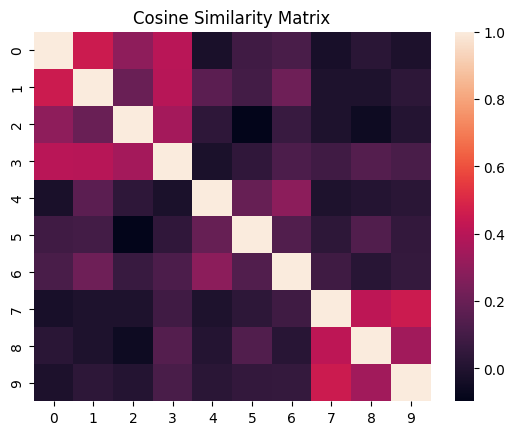

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(similarity_matrix)
plt.title("Cosine Similarity Matrix")
plt.show()

In [13]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

query_similarities = cosine_similarity(query_embedding, embeddings)[0]

query_similarities

array([ 0.5679121 ,  0.67298156,  0.20020553,  0.28086498,  0.10972209,
        0.06110454,  0.13323972,  0.02427393, -0.00754551, -0.01979667],
      dtype=float32)

In [14]:
import numpy as np

top_indices = np.argsort(query_similarities)[-2:][::-1]

for idx in top_indices:
    print("Sentence:", sentences[idx])
    print("Similarity Score:", query_similarities[idx])
    print()

Sentence: The bowler delivered a fast yorker to take the wicket.
Similarity Score: 0.67298156

Sentence: The batsman scored a century in the final match.
Similarity Score: 0.5679121

